<a href="https://colab.research.google.com/github/AnishIdhayan-1412/DS_HOT/blob/main/DataScience_HOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Install & Import Libraries
# All libraries are pre-installed in Google Colab

import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas version : {pd.__version__}')
print(f'NumPy  version : {np.__version__}')

Libraries loaded successfully.
Pandas version : 2.2.2
NumPy  version : 2.0.2


In [ ]:
import kagglehub
import os

# Step 2: Load IBM HR Analytics Dataset
# Direct download from a public mirror (no Kaggle API key needed)
dataset_path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print(f"Dataset downloaded to: {dataset_path}")

# Construct the full file path to the CSV file
file_name = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
file_path = os.path.join(dataset_path, file_name)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(df.head(3))

100%|██████████| 50.1k/50.1k [00:00<00:00, 19.5MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1
Dataset shape  : (1470, 35)
Columns        : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Resea

In [ ]:
# Step 3: Reconstruct Join_Date, Exit_Date, Last_Promotion_Date

TODAY = pd.Timestamp(date.today())

# Join_Date = today minus YearsAtCompany
df['Join_Date'] = TODAY - pd.to_timedelta(df['YearsAtCompany'] * 365.25, unit='D')
df['Join_Date'] = df['Join_Date'].dt.normalize()  # strip time component

# Exit_Date = None for active employees; Join + tenure for leavers
df['Exit_Date'] = np.where(
    df['Attrition'] == 'Yes',
    df['Join_Date'] + pd.to_timedelta(df['YearsAtCompany'] * 365.25, unit='D'),
    pd.NaT
)
df['Exit_Date'] = pd.to_datetime(df['Exit_Date'])

# Last_Promotion_Date = today minus YearsSinceLastPromotion
df['Last_Promotion_Date'] = TODAY - pd.to_timedelta(
    df['YearsSinceLastPromotion'] * 365.25, unit='D')
df['Last_Promotion_Date'] = df['Last_Promotion_Date'].dt.normalize()

print('Date columns created.')
print(df[['Join_Date','Exit_Date','Last_Promotion_Date','Attrition']].head(8))

Date columns created.
   Join_Date           Exit_Date Last_Promotion_Date Attrition
0 2020-05-05 2026-05-05 12:00:00          2026-05-06       Yes
1 2016-05-05                 NaT          2025-05-05        No
2 2026-05-06 2026-05-06 00:00:00          2026-05-06       Yes
3 2018-05-06                 NaT          2023-05-06        No
4 2024-05-05                 NaT          2024-05-05        No
5 2019-05-06                 NaT          2023-05-06        No
6 2025-05-05                 NaT          2026-05-06        No
7 2025-05-05                 NaT          2026-05-06        No


In [ ]:
# Step 4: Compute Tenure_Months
# Rule: for active employees (Exit_Date is NaT), use today as end date

def compute_tenure_months(row):
    start = row['Join_Date']
    end   = row['Exit_Date'] if pd.notna(row['Exit_Date']) else TODAY
    delta = (end.year - start.year) * 12 + (end.month - start.month)
    return max(delta, 0)  # never negative

df['Tenure_Months'] = df.apply(compute_tenure_months, axis=1)

print('--- Tenure_Months Statistics ---')
print(df['Tenure_Months'].describe())
print(f"\nEmployees with Tenure < 12 months : {(df['Tenure_Months'] < 12).sum()}")
print(f"Employees with Tenure > 120 months: {(df['Tenure_Months'] > 120).sum()}")

--- Tenure_Months Statistics ---
count    1470.000000
mean       84.097959
std        73.518302
min         0.000000
25%        36.000000
50%        60.000000
75%       108.000000
max       480.000000
Name: Tenure_Months, dtype: float64

Employees with Tenure < 12 months : 44
Employees with Tenure > 120 months: 246


In [ ]:
# Step 5: Compute Is_Promotion_Stagnant
# Definition: True if months since last promotion > 36 (3 years)

def months_since_promotion(row):
    ref_date = row['Exit_Date'] if pd.notna(row['Exit_Date']) else TODAY
    promo    = row['Last_Promotion_Date']
    return (ref_date.year - promo.year) * 12 + (ref_date.month - promo.month)

df['Months_Since_Promotion'] = df.apply(months_since_promotion, axis=1)
df['Is_Promotion_Stagnant']  = df['Months_Since_Promotion'] > 36

print('--- Is_Promotion_Stagnant Value Counts ---')
print(df['Is_Promotion_Stagnant'].value_counts())
stagnant_pct = df['Is_Promotion_Stagnant'].mean() * 100
print(f'\nPercentage of stagnant employees: {stagnant_pct:.1f}%')

--- Is_Promotion_Stagnant Value Counts ---
Is_Promotion_Stagnant
False    1149
True      321
Name: count, dtype: int64

Percentage of stagnant employees: 21.8%


In [ ]:
# Step 6: Validate & Preview

feature_cols = ['EmployeeNumber','Join_Date','Exit_Date',
                'Last_Promotion_Date','Tenure_Months',
                'Is_Promotion_Stagnant','Attrition']

print('=== Sample of engineered feature rows ===')
print(df[feature_cols].head(10).to_string())

# Sanity checks
assert (df['Tenure_Months'] >= 0).all(), 'Negative tenure found!'
assert df['Is_Promotion_Stagnant'].dtype == bool, 'Wrong dtype for flag!'
print('\nAll sanity checks PASSED.')

print('\n--- Attrition rate by Promotion Stagnancy ---')
print(df.groupby('Is_Promotion_Stagnant')['Attrition']
      .apply(lambda x: (x=='Yes').mean())
      .rename('Attrition_Rate'))

=== Sample of engineered feature rows ===
   EmployeeNumber  Join_Date           Exit_Date Last_Promotion_Date  Tenure_Months  Is_Promotion_Stagnant Attrition
0               1 2020-05-05 2026-05-05 12:00:00          2026-05-06             72                  False       Yes
1               2 2016-05-05                 NaT          2025-05-05            120                  False        No
2               4 2026-05-06 2026-05-06 00:00:00          2026-05-06              0                  False       Yes
3               5 2018-05-06                 NaT          2023-05-06             96                  False        No
4               7 2024-05-05                 NaT          2024-05-05             24                  False        No
5               8 2019-05-06                 NaT          2023-05-06             84                  False        No
6              10 2025-05-05                 NaT          2026-05-06             12                  False        No
7              11 2025

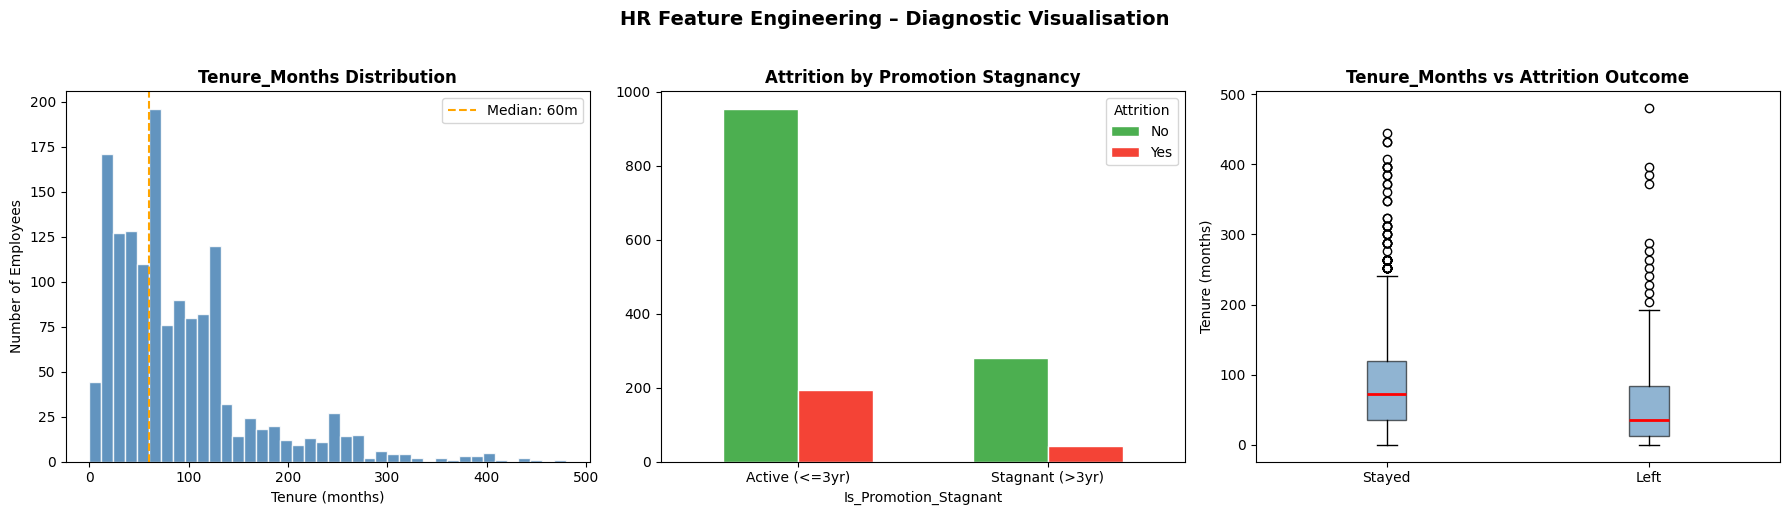

Figure saved as hr_feature_engineering.png


In [ ]:
# Step 7: Visualisation – 3-Panel Diagnostic Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HR Feature Engineering – Diagnostic Visualisation', fontsize=14, fontweight='bold', y=1.02)

# Panel 1: Tenure_Months Distribution
axes[0].hist(df['Tenure_Months'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Tenure_Months Distribution', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Employees')
axes[0].axvline(df['Tenure_Months'].median(), color='orange',
                linestyle='--', label=f"Median: {df['Tenure_Months'].median():.0f}m")
axes[0].legend()

# Panel 2: Promotion Stagnancy vs Attrition
attrition_by_stagnancy = df.groupby(['Is_Promotion_Stagnant','Attrition']).size().unstack()
attrition_by_stagnancy.plot(kind='bar', ax=axes[1],
    color=['#4CAF50','#F44336'], edgecolor='white', width=0.6)
axes[1].set_title('Attrition by Promotion Stagnancy', fontweight='bold')
axes[1].set_xlabel('Is_Promotion_Stagnant')
axes[1].set_xticklabels(['Active (<=3yr)', 'Stagnant (>3yr)'], rotation=0)
axes[1].legend(title='Attrition')

# Panel 3: Tenure vs Attrition (Box Plot)
left  = df[df['Attrition']=='No']['Tenure_Months']
right = df[df['Attrition']=='Yes']['Tenure_Months']
axes[2].boxplot([left, right], labels=['Stayed','Left'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Tenure_Months vs Attrition Outcome', fontweight='bold')
axes[2].set_ylabel('Tenure (months)')

plt.tight_layout()
plt.savefig('hr_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as hr_feature_engineering.png')

In [ ]:
# Step 8: Export Processed Dataset

output_cols = [c for c in df.columns
               if c not in ['Join_Date','Exit_Date','Last_Promotion_Date',
                             'Months_Since_Promotion']]
output_cols = ['EmployeeNumber','Tenure_Months','Is_Promotion_Stagnant',
               'Attrition'] + [c for c in output_cols
               if c not in ['EmployeeNumber','Tenure_Months',
                             'Is_Promotion_Stagnant','Attrition']]

df_export = df[output_cols].copy()
df_export.to_csv('hr_features_engineered.csv', index=False)

print(f'Exported {len(df_export)} rows x {len(df_export.columns)} columns')
print('Output file: hr_features_engineered.csv')
print(df_export[['EmployeeNumber','Tenure_Months','Is_Promotion_Stagnant',
                 'Attrition']].head(10))

Exported 1470 rows x 37 columns
Output file: hr_features_engineered.csv
   EmployeeNumber  Tenure_Months  Is_Promotion_Stagnant Attrition
0               1             72                  False       Yes
1               2            120                  False        No
2               4              0                  False       Yes
3               5             96                  False        No
4               7             24                  False        No
5               8             84                  False        No
6              10             12                  False        No
7              11             12                  False        No
8              12            108                  False        No
9              13             84                   True        No
